## Imports

In [37]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs



### Updates (temp)

In [2]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);


## Load Data

In [3]:
is_local_data = True

In [4]:
mean_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)
mean_mrsol_ds = model.shape_data.prune_group_ds_timespan(mean_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

var_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)
var_mrsol_ds = model.shape_data.prune_group_ds_timespan(var_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

#Wenn man sicher gehen will, das der Predictor die testdaten nicht kennen soll, kann man die testdaten auch erst nach dem Calibrieren berechnen
test_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)
test_mrsol_ds = model.shape_data.prune_group_ds_timespan(test_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

In [5]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

mean_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

var_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

test_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### Mask and Stack Data

In [6]:
mean_mrsol_masked_ds, mask = model.mask.mask_nonpositiv_height_chunks(mean_mrsol_ds)
mean_input_masked_ds = model.mask.mask_mask(mean_input_ds,mask)

var_mrsol_masked_ds , mask_1 = model.mask.mask_nonpositiv_height_chunks(var_mrsol_ds)
var_input_masked_ds = model.mask.mask_mask(var_input_ds,mask)

test_mrsol_masked_ds, mask_2 = model.mask.mask_nonpositiv_height_chunks(test_mrsol_ds)
test_input_masked_ds = model.mask.mask_mask(test_input_ds,mask)

In [7]:
#(mask != mask_2).sum()

In [8]:
mean_mrsol_stack_ds = mesmer.grid.stack_lat_lon(mean_mrsol_masked_ds)
var_mrsol_stack_ds = mesmer.grid.stack_lat_lon(var_mrsol_masked_ds)
test_mrsol_stack_ds = mesmer.grid.stack_lat_lon(test_mrsol_masked_ds)
mean_input_stack_ds = mesmer.grid.stack_lat_lon(mean_input_masked_ds)
var_input_stack_ds = mesmer.grid.stack_lat_lon(var_input_masked_ds)
test_input_stack_ds = mesmer.grid.stack_lat_lon(test_input_masked_ds)

### Transform Data

In [9]:
mean_mrsol_t = model.transform.Log_Transform_ds(mean_mrsol_stack_ds)
var_mrsol_t = model.transform.Log_Transform_ds(var_mrsol_stack_ds)
test_mrsol_t = model.transform.Log_Transform_ds(test_mrsol_stack_ds)

### Linaer Regression of the mean

In [10]:
mean_predictors = mean_input_stack_ds
mean_target_da = mean_mrsol_t.mrsol

In [11]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [12]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [13]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [14]:
var_predictors = var_input_stack_ds
var_target_ds = var_mrsol_t

In [15]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [16]:
residuals_t

<xarray.Dataset> Size: 3MB
Dimensions:    (depth: 5, time: 165, gridcell: 378)
Coordinates:
  * depth      (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time       (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
    lat        (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon        (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
    height     float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    residuals  (time, depth, gridcell) float64 2MB -0.0003309 ... -2.132e-14

### Linear Regression of the Variance

In [17]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [18]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [19]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7fa846a1e660>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7fa83decb110>)

### Export Prameters

In [20]:
#model.save.save_params()

### Example Emulation

In [21]:
test_predictors = test_input_stack_ds
test_target_ds = test_mrsol_t.transpose("gridcell","time", "depth")

In [22]:
test_mean_prediction = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [23]:
test_var_prediction = LinReg_variance.predict(test_predictors).clip(min = 1e-32).transpose("gridcell","time", "depth")

In [24]:
var_prediction_da=test_var_prediction.prediction
mean_prediction_da = test_mean_prediction.prediction
target_da_t = test_target_ds.mrsol

### crpss Score

In [25]:
importlib.reload(model_analysis.crps_score);

scheinbar wächst die laufzeit in der ensemble_size mehr als linear, sieht schlimmer als quadratisch aus:(

5->0.5s

10->1.3s

20->4.2s

40->15s

80->1min 54s

In [ ]:
score, space_score = model_analysis.crps_score.crps_ensemble_score(test_mean_prediction, test_var_prediction,test_target_ds,transformation="Log",ensemble_size=80)

In [36]:
score.isel(depth=0).mean("time")

<xarray.Dataset> Size: 9kB
Dimensions:     (gridcell: 378)
Coordinates:
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
    depth       float64 8B 0.03
Dimensions without coordinates: gridcell
Data variables:
    prediction  (gridcell) float64 3kB 0.2203 0.2721 ... 0.02228 8.273e-08

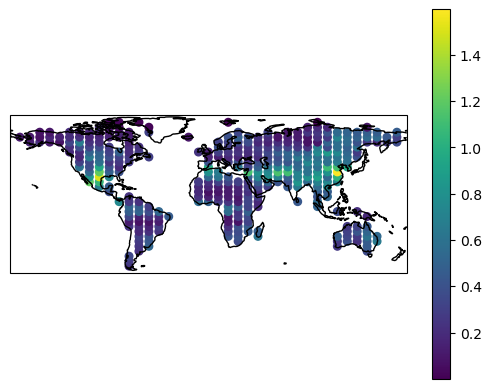

In [43]:
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

da = score.isel(depth=0).mean("time").prediction
sc = ax.scatter(
    da.lon,
    da.lat,
    c=da,
    s=30,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

cbar = plt.colorbar(sc, ax=ax)

In [ ]:
score.rename_vars()

<xarray.Dataset> Size: 3MB
Dimensions:     (depth: 5, time: 165, gridcell: 378)
Coordinates:
  * depth       (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time        (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
    lat         (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon         (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
Dimensions without coordinates: gridcell
Data variables:
    prediction  (depth, time, gridcell) float64 2MB 0.3985 0.1559 ... 1.582e-18